# Problem 3:

Part 1:

True negatives do **not** matter the same way for ROC and PR.

For ROC, each point is $(\mathrm{FPR}, \mathrm{TPR})$, where:

$$\mathrm{TPR}=\frac{TP}{TP+FN}, \qquad \mathrm{FPR}=\frac{FP}{FP+TN}$$

So ROC explicitly depends on $TN$ through $\mathrm{FPR}$.

For PR, each point is $(\mathrm{Recall}, \mathrm{Precision})$, where:

$$\mathrm{Recall}=\frac{TP}{TP+FN}, \qquad \mathrm{Precision}=\frac{TP}{TP+FP}$$

$TN$ does not appear in either expression, so PR is not directly affected by true negatives.

Why a ROC point maps to a unique PR point (for a fixed dataset):

Let $P$ be the number of positives, $N$ the number of negatives, and prevalence $\pi=\frac{P}{P+N}$. Given a ROC point $(\mathrm{TPR},\mathrm{FPR})$, we can compute:

$$\mathrm{Recall}=\mathrm{TPR}$$

$$\mathrm{Precision}=\frac{\pi\,\mathrm{TPR}}{\pi\,\mathrm{TPR}+(1-\pi)\,\mathrm{FPR}}$$

Since $\pi$ is fixed for the dataset, each ROC point produces exactly one precision value, hence one unique PR point.

Part 2:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, precision_recall_curve, auc

In [2]:
seed = 301
data_id = 44  # OpenML spambase (binary classification)

dataset = fetch_openml(data_id=data_id, as_frame=True)
X = dataset.data
y = dataset.target.astype(str)

labels = sorted(y.unique())
negative_label, positive_label = labels[0], labels[1]
y_bin = (y == positive_label).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=seed, stratify=y_bin
)

print('OpenML data_id:', data_id)
print('Dataset name:', dataset.details.get('name', 'spambase'))
print('Original class labels:', labels)
print('Positive class label used for curves:', positive_label)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

OpenML data_id: 44
Dataset name: spambase
Original class labels: ['0', '1']
Positive class label used for curves: 1
Train shape: (3680, 57)  Test shape: (921, 57)


In [3]:
ada = AdaBoostClassifier(random_state=seed)
logreg = LogisticRegression(max_iter=3000, random_state=seed)

ada.fit(X_train, y_train)
logreg.fit(X_train, y_train)

ada_scores = ada.predict_proba(X_test)[:, 1]
logreg_scores = logreg.predict_proba(X_test)[:, 1]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [4]:
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_scores)
fpr_log, tpr_log, _ = roc_curve(y_test, logreg_scores)

auc_ada = auc(fpr_ada, tpr_ada)
auc_log = auc(fpr_log, tpr_log)

P = int((y_test == 1).sum())
N = int((y_test == 0).sum())
all_pos_roc_fpr = 1.0
all_pos_roc_tpr = 1.0

print(f'Test positives (P): {P}')
print(f'Test negatives (N): {N}')
print('All-positive ROC point: (FPR, TPR) = (1.0000, 1.0000)')

Test positives (P): 363
Test negatives (N): 558
All-positive ROC point: (FPR, TPR) = (1.0000, 1.0000)


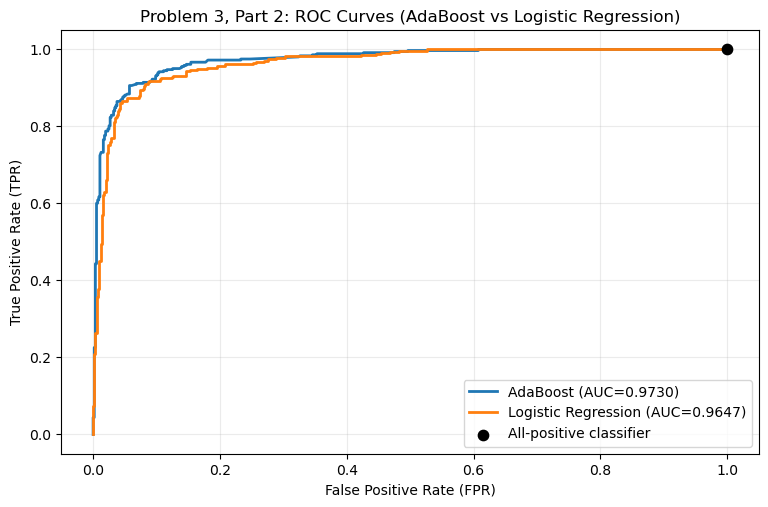

In [5]:
plt.figure(figsize=(9, 5.5))
plt.plot(fpr_ada, tpr_ada, linewidth=2, label=f'AdaBoost (AUC={auc_ada:.4f})')
plt.plot(fpr_log, tpr_log, linewidth=2, label=f'Logistic Regression (AUC={auc_log:.4f})')
plt.scatter([all_pos_roc_fpr], [all_pos_roc_tpr], color='black', s=55, zorder=5, label='All-positive classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Problem 3, Part 2: ROC Curves (AdaBoost vs Logistic Regression)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [6]:
prec_ada, rec_ada, _ = precision_recall_curve(y_test, ada_scores)
prec_log, rec_log, _ = precision_recall_curve(y_test, logreg_scores)

pr_auc_ada = auc(rec_ada, prec_ada)
pr_auc_log = auc(rec_log, prec_log)

all_pos_precision = P / (P + N)
all_pos_recall = 1.0

print(f'All-positive PR point calculation:')
print(f'Precision = P/(P+N) = {P}/({P}+{N}) = {all_pos_precision:.4f}')
print('Recall = 1.0000')

All-positive PR point calculation:
Precision = P/(P+N) = 363/(363+558) = 0.3941
Recall = 1.0000


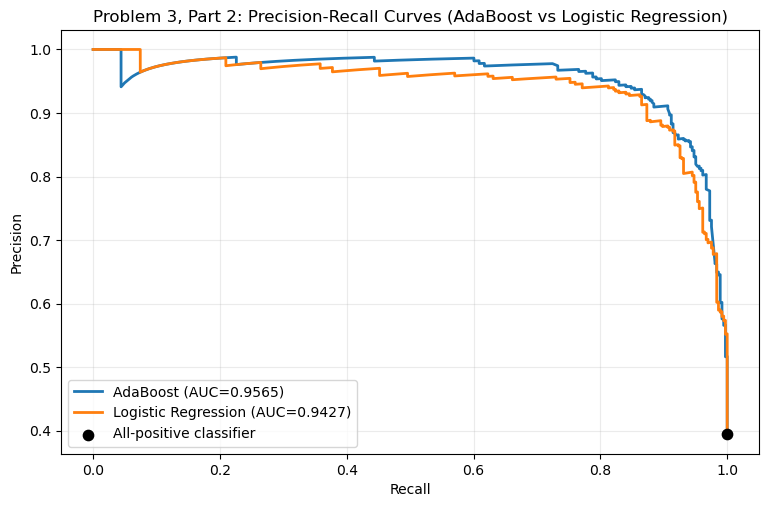

In [7]:
plt.figure(figsize=(9, 5.5))
plt.plot(rec_ada, prec_ada, linewidth=2, label=f'AdaBoost (AUC={pr_auc_ada:.4f})')
plt.plot(rec_log, prec_log, linewidth=2, label=f'Logistic Regression (AUC={pr_auc_log:.4f})')
plt.scatter([all_pos_recall], [all_pos_precision], color='black', s=55, zorder=5, label='All-positive classifier')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Problem 3, Part 2: Precision-Recall Curves (AdaBoost vs Logistic Regression)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

Both ROC and PR figures include the all-positive classifier point. In ROC space this point is always $(1,1)$. In PR space it is $(\text{Recall}=1,\text{Precision}=\pi)$, where $\pi$ is the positive-class prevalence in the test set.